# IY031 – TF Identity Classification: NEW Dataset (12-class, IY021 sanity check)

**Goal:** Classify time series by **TF identity** (pooling across conditions) comparing three classifiers:
1. **Raw SVM (RBF)** — truncated time series as a flat feature vector
2. **Catch22 + SVM** — 22 canonical time-series features (length-agnostic)
3. **SimCLR + SVM** — pre-trained transformer embeddings (IY017/022/023/024 checkpoints)

**Datasets:** Steady-state (`4_transformed_exp_time_series_NEW/`) and Full (`5_FULL_transformed_exp_time_series_NEW/`)
**Class selection:** Fixed 12 TFs matching the IY021 sanity-check panel: OPI1, MSN2, YOX1, TEA1, ROX1, SOK2, CUP9, SPT15, CBF1, STB5, CIN5, RSC3. Labels = TF name only (conditions pooled).
**Excluded TF labels:** `Empty`, `Gcd6_Poss_Mix`, `Sse2_Poss_Mix`.
**Note:** Raw SVM and Catch22 use un-normalised traces; SimCLR uses batch-wise z-score per timepoint.

In [1]:
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pycatch22
import torch
from pathlib import Path
from matplotlib.patches import Patch
from IPython.display import display
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm.auto import tqdm

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
from models.ssl_transformer import SSL_Transformer

RANDOM_STATE = 42

EXCLUDED_TFS = {"Empty", "Gcd6_Poss_Mix", "Sse2_Poss_Mix"}

# Fixed 12-class selection: TF identity only (conditions pooled), matching IY021 sanity-check panel
# Names as they appear in the metadata (title-case)
FIXED_TFS = {"Opi1", "Msn2", "Yox1", "Tea1", "Rox1", "Sok2", "Cup9", "Spt15", "Cbf1", "Stb5", "Cin5", "Rsc3"}

IY031_DIR     = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY031")
IY008_DIR     = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008")
EXP_DIR       = Path("/home/ianyang/stochastic_simulations/experiments")
SS_DATA_DIR   = IY008_DIR / "4_transformed_exp_time_series_NEW"
FULL_DATA_DIR = IY008_DIR / "5_FULL_transformed_exp_time_series_NEW"
META_PATH     = IY008_DIR / "NEW_data_metadata.csv"
META_COLS     = ["id", "group", "experiment"]

FILE_RE = re.compile(r"^(\d+)_group_(.+?)_(GFP|mCherry)_time_series$")
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif", "axes.titlesize": 14,
    "axes.labelsize": 12, "xtick.labelsize": 10,
    "ytick.labelsize": 10, "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")
print(f"Device: {DEVICE}")

Device: cuda


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Metadata & Label Lookup

In [2]:
metadata = pd.read_csv(META_PATH)
metadata["exp_id"]   = metadata["exp_id"].astype(str)
metadata["group_id"] = metadata["group_id"].astype(str)

LABEL_LOOKUP = {
    (row.exp_id, row.group_id, row.channel): (row.tf, row.condition)
    for _, row in metadata.iterrows()
    if row.tf not in EXCLUDED_TFS
}

print(f"Metadata entries: {len(metadata)}  (after excluding noisy TFs: {len(LABEL_LOOKUP)})")
print("Unique conditions:", sorted({v[1] for v in LABEL_LOOKUP.values()}))


Metadata entries: 639  (after excluding noisy TFs: 636)
Unique conditions: ['0% glucose', 'low N₂']


## 2. Load Datasets

In [3]:
from utils.experimental_time_series import load_labelled_time_series_csvs
"""Scan data_dir for time-series CSVs; assign TF@condition labels via metadata."""

print("=" * 70)
print(f"STEADY-STATE  ({SS_DATA_DIR.name})")
print("=" * 70)
ss_ts_raw, ss_label_strs = load_labelled_time_series_csvs(
        data_dir=SS_DATA_DIR,
        file_re=FILE_RE,
        label_lookup=LABEL_LOOKUP,
        meta_cols=META_COLS,
        label_fn=lambda tf, condition: tf,
        verbose=False,
    )
print(f"Loaded {len(ss_ts_raw)} files, {len(ss_label_strs)} total cells  ({SS_DATA_DIR.name})")

print("=" * 70)
print(f"FULL  ({FULL_DATA_DIR.name})")
print("=" * 70)
full_ts_raw, full_label_strs = load_labelled_time_series_csvs(
        data_dir=FULL_DATA_DIR,
        file_re=FILE_RE,
        label_lookup=LABEL_LOOKUP,
        meta_cols=META_COLS,
        label_fn=lambda tf, condition: tf,
        verbose=False,
    )
print(f"Loaded {len(full_ts_raw)} files, {len(full_label_strs)} total cells  ({FULL_DATA_DIR.name})")


STEADY-STATE  (4_transformed_exp_time_series_NEW)


Loaded 598 files, 20770 total cells  (4_transformed_exp_time_series_NEW)
FULL  (5_FULL_transformed_exp_time_series_NEW)


Loaded 636 files, 22038 total cells  (5_FULL_transformed_exp_time_series_NEW)


## 3. Class Selection

In [4]:
def print_class_summary(label_strs, kept_tfs, dataset_name):
    counts = pd.Series(label_strs).value_counts().sort_index()
    kept   = sorted(kept_tfs)
    print(f"{dataset_name} -- {len(counts)} total TF classes, {len(label_strs)} total cells")
    print(f"  Fixed {len(kept)}-class selection (IY021 sanity check):")
    for cls in kept:
        cnt = counts.get(cls, 0)
        print(f"  {cls:20s}: {cnt:5d}")
    missing = [c for c in kept if counts.get(c, 0) == 0]
    if missing:
        print(f"  WARNING: TFs with no data: {missing}")
    print(f"  -> Using {len(kept)} classes")
    print(f"  Chance: 1/{len(kept)} = {1/len(kept):.4f}")
    return kept


print()
ss_kept_classes   = print_class_summary(ss_label_strs,   FIXED_TFS, "Steady-state")
print()
full_kept_classes = print_class_summary(full_label_strs, FIXED_TFS, "Full")


Steady-state -- 138 total TF classes, 20770 total cells
  Fixed 12-class selection (IY021 sanity check):
  Cbf1                :   365
  Cin5                :   275
  Cup9                :   250
  Msn2                :   507
  Opi1                :   495
  Rox1                :   402
  Rsc3                :   338
  Sok2                :   289
  Spt15               :   317
  Stb5                :   251
  Tea1                :   316
  Yox1                :   426
  -> Using 12 classes
  Chance: 1/12 = 0.0833

Full -- 140 total TF classes, 22038 total cells
  Fixed 12-class selection (IY021 sanity check):
  Cbf1                :   365
  Cin5                :   275
  Cup9                :   250
  Msn2                :   507
  Opi1                :   495
  Rox1                :   402
  Rsc3                :   338
  Sok2                :   289
  Spt15               :   317
  Stb5                :   251
  Tea1                :   316
  Yox1                :   426
  -> Using 12 classes
  Chance

## 4. Preprocessing

In [5]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from utils.processing.pipeline import prepare_dataset

print("--- Steady-state ---")
ss = prepare_dataset(ss_ts_raw, ss_label_strs, ss_kept_classes, "Steady-state")
print()
print("--- Full ---")
full = prepare_dataset(full_ts_raw, full_label_strs, full_kept_classes, "Full")

--- Steady-state ---
Steady-state: 4231 cells × 17 tp, 12 classes, NaN remaining: 0
  Balancing to 250 cells/class
  Train: 2400  |  Test: 600

--- Full ---
Full: 4231 cells × 24 tp, 12 classes, NaN remaining: 0
  Balancing to 250 cells/class
  Train: 2400  |  Test: 600


## 5. Trace Overview

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY031/IY031_NEW_tf_condition_ss_balanced_traces.png


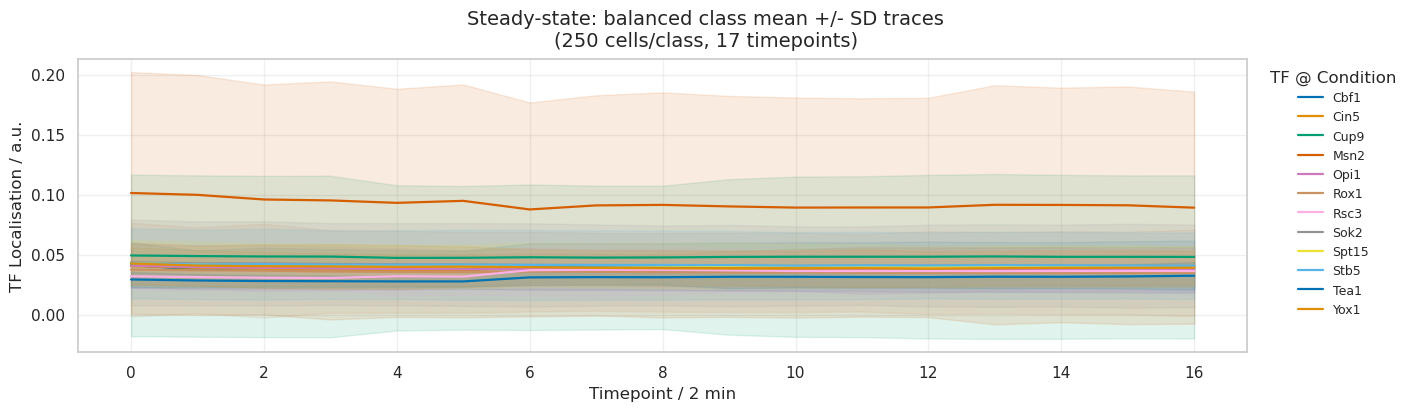

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY031/IY031_NEW_tf_condition_full_balanced_traces.png


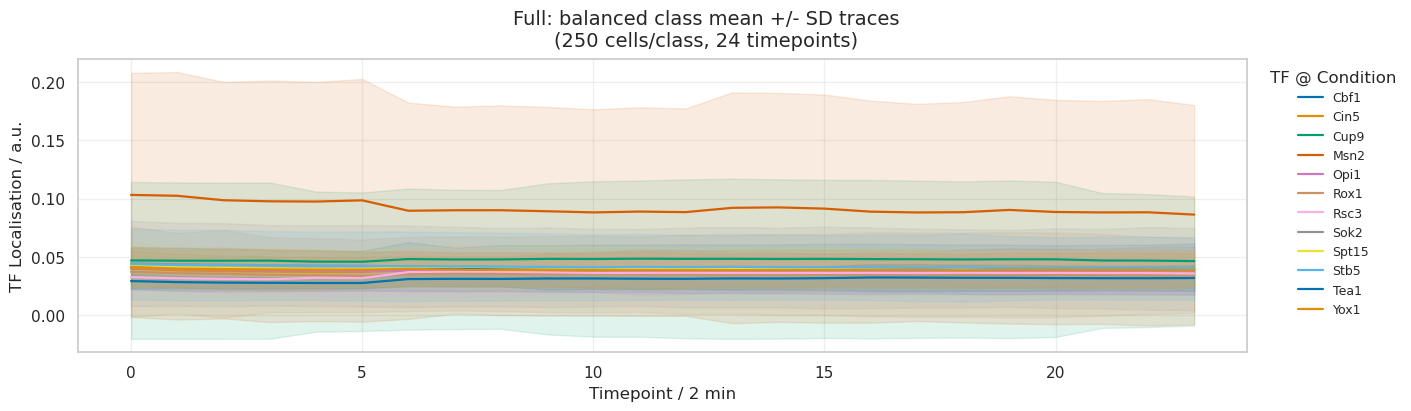

In [6]:
def plot_balanced_traces(d, dataset_tag, fig_path):
    'Mean +/- SD traces per class for the balanced (un-normalised) dataset.'
    X_bal       = d["X_bal"]
    y_bal       = d["y_bal"]
    class_names = d["class_names"]
    n_cls       = len(class_names)
    n_tp        = X_bal.shape[1]
    palette     = sns.color_palette("colorblind", n_colors=n_cls)

    fig, ax = plt.subplots(figsize=(14, 4), constrained_layout=True)
    for i, cls in enumerate(class_names):
        mask = y_bal == i
        mean = X_bal[mask].mean(axis=0)
        sd   = X_bal[mask].std(axis=0, ddof=1)
        ax.plot(np.arange(n_tp), mean, label=cls, color=palette[i], linewidth=1.6)
        ax.fill_between(np.arange(n_tp), mean - sd, mean + sd, color=palette[i], alpha=0.12)
    ax.set_xlabel("Timepoint / 2 min")
    ax.set_ylabel("TF Localisation / a.u.")
    ax.grid(alpha=0.3)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False,
              title="TF @ Condition", fontsize=9)
    fig.suptitle(f"{dataset_tag}: balanced class mean +/- SD traces\n"
                 f"({d['min_count']} cells/class, {n_tp} timepoints)", fontsize=14)
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")
    plt.show()


plot_balanced_traces(ss,   "Steady-state",
                    IY031_DIR / "IY031_NEW_tf_condition_ss_balanced_traces.png")
plot_balanced_traces(full, "Full",
                    IY031_DIR / "IY031_NEW_tf_condition_full_balanced_traces.png")


## 6. Raw SVM

In [7]:
def run_raw_svm(d, dataset_tag):
    'RBF-SVM on flat truncated (un-normalised) time series.'
    print(f"\n=== Raw SVM (RBF) -- {dataset_tag} (T={d['min_T']}) ===")
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm",    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
    ])
    pipe.fit(d["X_train_raw"], d["y_train"])
    y_pred = pipe.predict(d["X_test_raw"])
    acc    = accuracy_score(d["y_test"], y_pred)
    print(f"Accuracy: {acc:.4f}  (chance={1/len(d['class_names']):.4f})")
    print(classification_report(d["y_test"], y_pred, target_names=d["class_names"]))
    return acc, y_pred

ss_svm_acc,   ss_svm_pred   = run_raw_svm(ss,   "Steady-state")
full_svm_acc, full_svm_pred = run_raw_svm(full, "Full")



=== Raw SVM (RBF) -- Steady-state (T=17) ===


Accuracy: 0.2183  (chance=0.0833)
              precision    recall  f1-score   support

        Cbf1       0.50      0.02      0.04        50
        Cin5       0.09      0.04      0.05        50
        Cup9       0.36      0.66      0.47        50
        Msn2       0.42      0.36      0.39        50
        Opi1       0.00      0.00      0.00        50
        Rox1       0.18      0.32      0.23        50
        Rsc3       0.53      0.16      0.25        50
        Sok2       0.10      0.16      0.12        50
       Spt15       0.12      0.16      0.14        50
        Stb5       0.00      0.00      0.00        50
        Tea1       0.21      0.74      0.33        50
        Yox1       0.00      0.00      0.00        50

    accuracy                           0.22       600
   macro avg       0.21      0.22      0.17       600
weighted avg       0.21      0.22      0.17       600


=== Raw SVM (RBF) -- Full (T=24) ===


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

Accuracy: 0.2200  (chance=0.0833)
              precision    recall  f1-score   support

        Cbf1       0.00      0.00      0.00        50
        Cin5       0.22      0.04      0.07        50
        Cup9       0.42      0.66      0.52        50
        Msn2       0.36      0.42      0.39        50
        Opi1       0.14      0.02      0.04        50
        Rox1       0.11      0.08      0.09        50
        Rsc3       0.39      0.18      0.25        50
        Sok2       0.14      0.16      0.15        50
       Spt15       0.12      0.24      0.16        50
        Stb5       0.00      0.00      0.00        50
        Tea1       0.18      0.84      0.30        50
        Yox1       0.00      0.00      0.00        50

    accuracy                           0.22       600
   macro avg       0.18      0.22      0.16       600
weighted avg       0.18      0.22      0.16       600



/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

## 7. Catch22 + SVM

Features are length-agnostic — extracted from full-length series.

In [8]:
from features.catch22 import run_catch22_series_svm

ss_c22_acc,   ss_c22_pred   = run_catch22_series_svm(ss,   "Steady-state", random_state=RANDOM_STATE)
full_c22_acc, full_c22_pred = run_catch22_series_svm(full, "Full", random_state=RANDOM_STATE)



=== Catch22 + SVM (RBF) -- Steady-state ===


Train:   0%|          | 0/2400 [00:00<?, ?it/s]

Train:  53%|█████▎    | 1272/2400 [00:00<00:00, 12712.25it/s]

Test:   0%|          | 0/600 [00:00<?, ?it/s]

Feature matrix: 22 features


...

Train:  43%|████▎     | 1037/2400 [00:00<00:00, 10363.02it/s]

Train:  86%|████████▋ | 2074/2400 [00:00<00:00, 10328.26it/s]

Test:   0%|          | 0/600 [00:00<?, ?it/s]

Feature matrix: 22 features


Accuracy: 0.2150  (chance=0.0833)
              precision    recall  f1-score   support

        Cbf1       0.14      0.10      0.12        50
        Cin5       0.10      0.06      0.07        50
        Cup9       0.30      0.48      0.37        50
        Msn2       0.24      0.32      0.27        50
        Opi1       0.24      0.18      0.20        50
        Rox1       0.10      0.06      0.08        50
        Rsc3       0.13      0.16      0.14        50
        Sok2       0.21      0.20      0.20        50
       Spt15       0.26      0.28      0.27        50
        Stb5       0.20      0.26      0.22        50
        Tea1       0.38      0.36      0.37        50
        Yox1       0.14      0.12      0.13        50

    accuracy                           0.21       600
   macro avg       0.20      0.21      0.20       600
weighted avg       0.20      0.21      0.20       600



## 8. SimCLR Model Registry

In [9]:
from utils.embeddings import load_simclr_model, encode_channel

NORM_OVERRIDES = {
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_125632_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_132219_model": "joint",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_125550_model": "global",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165118_model": "joint",
}


from utils.embeddings import parse_arch_from_name as parse_arch


from functools import partial
from utils.embeddings import (
    make_checkpoint_short_label,
    make_unique_checkpoint_label,
)

make_short_label = partial(
    make_checkpoint_short_label,
    norm_overrides=NORM_OVERRIDES,
)
make_unique_label = partial(
    make_unique_checkpoint_label,
    norm_overrides=NORM_OVERRIDES,
)

CKPT_DIRS      = ["EXP-26-IY017", "EXP-26-IY022", "EXP-26-IY023", "EXP-26-IY024"]
MODEL_REGISTRY = []
for idx, _d in enumerate(CKPT_DIRS):
    for p in sorted((EXP_DIR / _d).glob("*.pth")):
        MODEL_REGISTRY.append({
            "path": p,
            "short_label": make_short_label(p),
            "label": make_unique_label(p, len(MODEL_REGISTRY)),
            "experiment": _d,
        })

EXP_COLOR_MAP = {
    "EXP-26-IY017": sns.color_palette("colorblind")[0],
    "EXP-26-IY022": sns.color_palette("colorblind")[1],
    "EXP-26-IY023": sns.color_palette("colorblind")[2],
    "EXP-26-IY024": sns.color_palette("colorblind")[4],
}

print(f"Found {len(MODEL_REGISTRY)} checkpoints:")
for row in MODEL_REGISTRY:
    arch = parse_arch(row["path"].name)
    print(f"  [{row['experiment']}]  {row['label']:<52s}  d_model={arch['d_model']}")


def run_simclr_svm(model, X_tr, X_te, y_tr, y_te, device):
    'Encode -> StandardScale -> RBF-SVM; return (accuracy, y_pred).'
    Z_tr    = encode_channel(model, X_tr, device)
    Z_te    = encode_channel(model, X_te, device)
    scaler  = StandardScaler()
    Z_tr_sc = scaler.fit_transform(Z_tr)
    Z_te_sc = scaler.transform(Z_te)
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
    clf.fit(Z_tr_sc, y_tr)
    y_pred = clf.predict(Z_te_sc)
    return accuracy_score(y_te, y_pred), y_pred

Found 34 checkpoints:
  [EXP-26-IY017]  IY017-inst b100 D128 #00                              d_model=128
  [EXP-26-IY017]  IY017-inst b100 D128 #01                              d_model=128
  [EXP-26-IY017]  IY017-inst b1024 D16 164413                           d_model=16
  [EXP-26-IY017]  IY017-inst b1024 D16 061239                           d_model=16
  [EXP-26-IY017]  IY017-inst b128 D16 151037                            d_model=16
  [EXP-26-IY017]  IY017-inst b16 D16 #05                                d_model=16
  [EXP-26-IY017]  IY017-inst b16 D16 #06                                d_model=16
  [EXP-26-IY017]  IY017-inst b2048 D16 162432                           d_model=16
  [EXP-26-IY017]  IY017-inst b256 D16 154425                            d_model=16
  [EXP-26-IY017]  IY017-inst b32 D128 #09                               d_model=128
  [EXP-26-IY017]  IY017-inst b4096 D16 140729                           d_model=16
  [EXP-26-IY017]  IY017-inst b4096 D16 023947                 

## 9. Run SimCLR Models

In [10]:
def run_all_models(d, dataset_name, csv_tag):
    'Evaluate all checkpoints; return results DataFrame and predictions dict.'
    rows, preds = [], {}
    n_cls  = len(d["class_names"])
    chance = 1.0 / n_cls
    print(f"  {n_cls} classes, chance={chance:.4f}")
    for row in MODEL_REGISTRY:
        ckpt_path = row["path"]
        print(f"  {row['label']:<55s}", end=" ")
        try:
            model = load_simclr_model(ckpt_path, DEVICE)
            acc, y_pred = run_simclr_svm(
                model,
                d["X_train"], d["X_test"],
                d["y_train"], d["y_test"],
                DEVICE
            )
            preds[str(ckpt_path)] = y_pred
            rows.append({
                "label":           row["label"],
                "short_label":     row["short_label"],
                "experiment":      row["experiment"],
                "checkpoint":      str(ckpt_path),
                "checkpoint_name": ckpt_path.name,
                "accuracy":        acc,
                "status":          "ok",
                "error":           "",
            })
            print(f"acc={acc:.4f}  (+{acc - chance:.4f})")
        except Exception as exc:
            rows.append({
                "label": row["label"], "short_label": row["short_label"],
                "experiment": row["experiment"],
                "checkpoint": str(ckpt_path), "checkpoint_name": ckpt_path.name,
                "accuracy": np.nan, "status": "failed", "error": str(exc),
            })
            print(f"FAILED: {exc}")

    results_df = (
        pd.DataFrame(rows)
        .sort_values("accuracy", ascending=False, na_position="last")
        .reset_index(drop=True)
    )
    csv_path = IY031_DIR / f"{csv_tag}_simclr_results.csv"
    results_df.to_csv(csv_path, index=False)
    print(f"\nSaved: {csv_path}")
    return results_df, preds


print("=" * 70)
print("STEADY-STATE dataset")
print("=" * 70)
ss_simclr_df,   ss_simclr_preds   = run_all_models(ss,   "ss",   "IY031_NEW_tf_condition_ss")

print()
print("=" * 70)
print("FULL dataset")
print("=" * 70)
full_simclr_df, full_simclr_preds = run_all_models(full, "full", "IY031_NEW_tf_condition_full")

STEADY-STATE dataset
  12 classes, chance=0.0833
  IY017-inst b100 D128 #00                                

SimCLR encode:   0%|          | 0/10 [00:00<?, ?it/s]

SimCLR encode:   0%|          | 0/3 [00:00<?, ?it/s]

acc=0.2450  (+0.1617)
  IY017-inst b100 D128 #01                                

SimCLR encode:   0%|          | 0/10 [00:00<?, ?it/s]

...

SimCLR encode:   0%|          | 0/3 [00:00<?, ?it/s]

acc=0.2750  (+0.1917)
  IY024-batch b64 D8 203126                               

SimCLR encode:   0%|          | 0/10 [00:00<?, ?it/s]

SimCLR encode:   0%|          | 0/3 [00:00<?, ?it/s]

acc=0.2500  (+0.1667)

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY031/IY031_NEW_tf_condition_full_simclr_results.csv


## 10. Results Comparison

- **SimCLR bar chart** with Raw SVM & Catch22+SVM as reference lines
- **Summary** grouped bar: Raw SVM vs Catch22+SVM vs best SimCLR
- **Confusion matrices**: 3 methods × 2 datasets (SS and Full)

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY031/IY031_NEW_tf_condition_ss_simclr_results.png


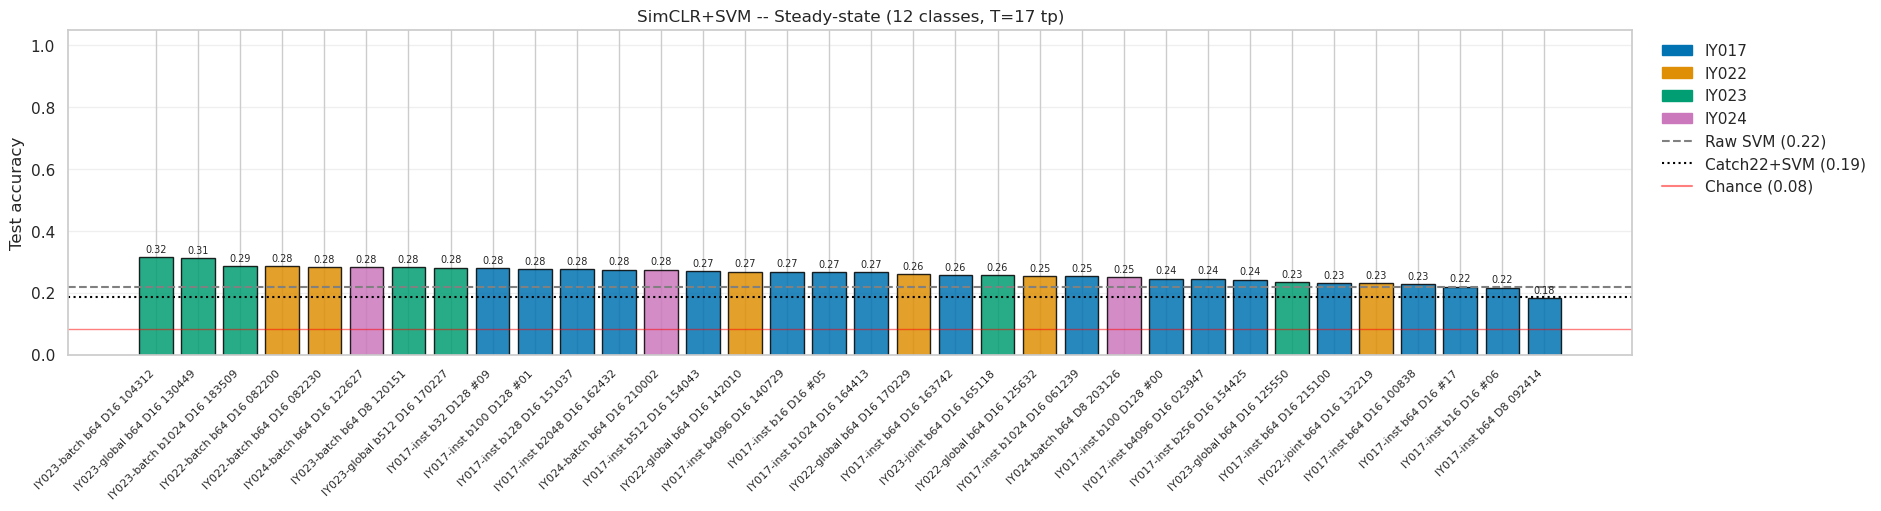

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY031/IY031_NEW_tf_condition_full_simclr_results.png


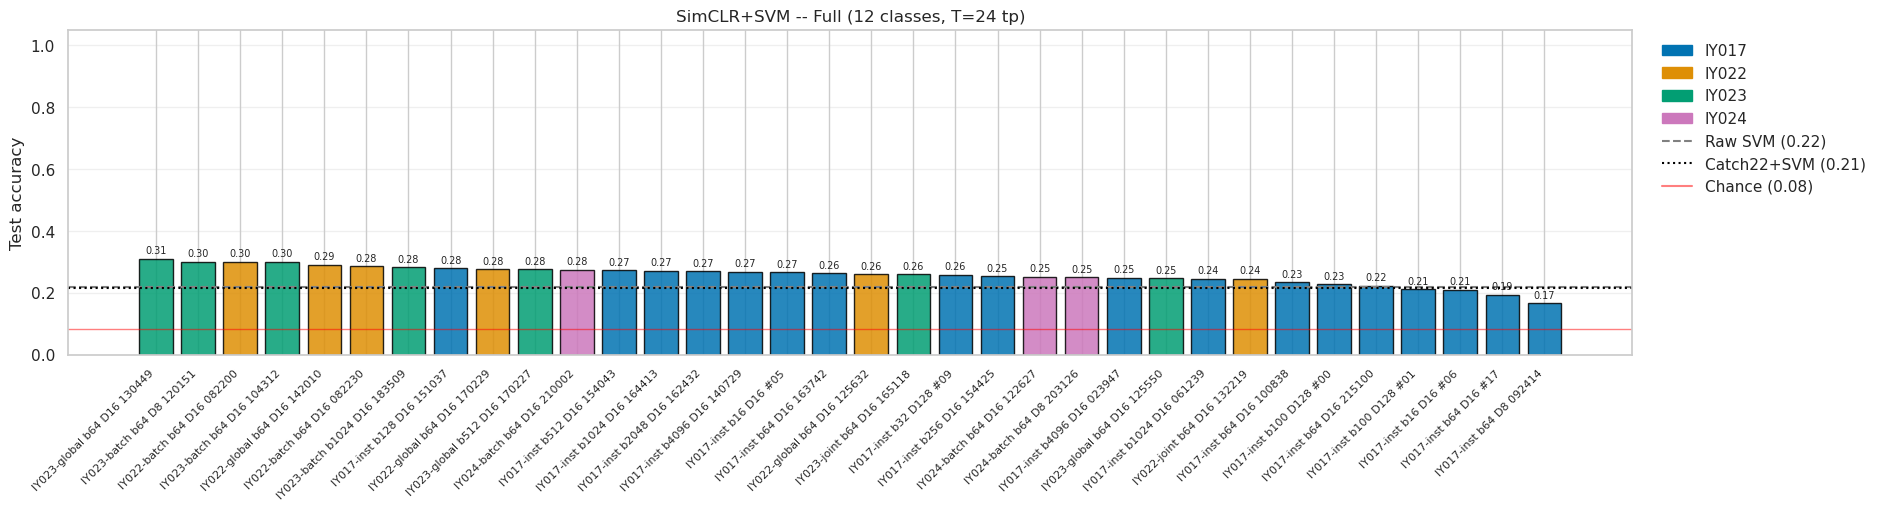

Saved: IY031_NEW_tf_condition_summary_comparison.png


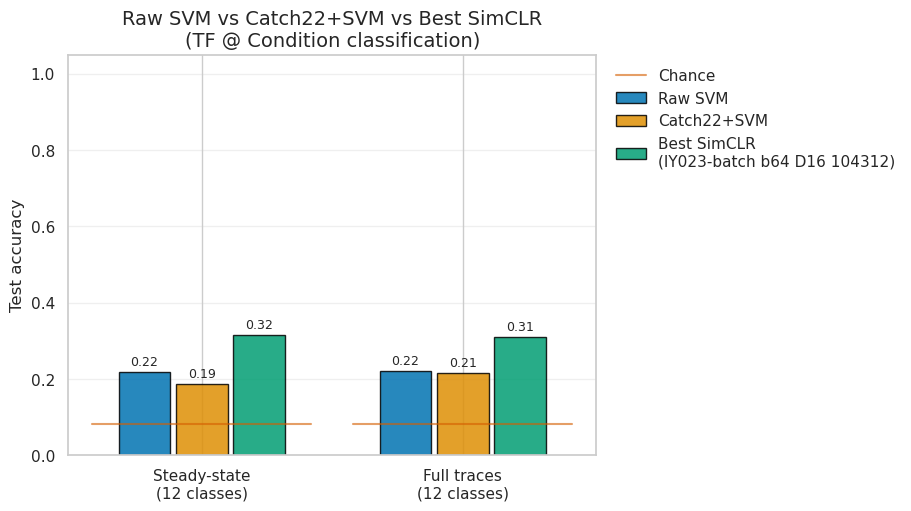


Best SimCLR -- SS:   IY023-batch b64 D16 104312  acc=0.3150
Best SimCLR -- Full: IY023-global b64 D16 130449  acc=0.3100


Saved: IY031_NEW_tf_condition_confusion_matrices.png


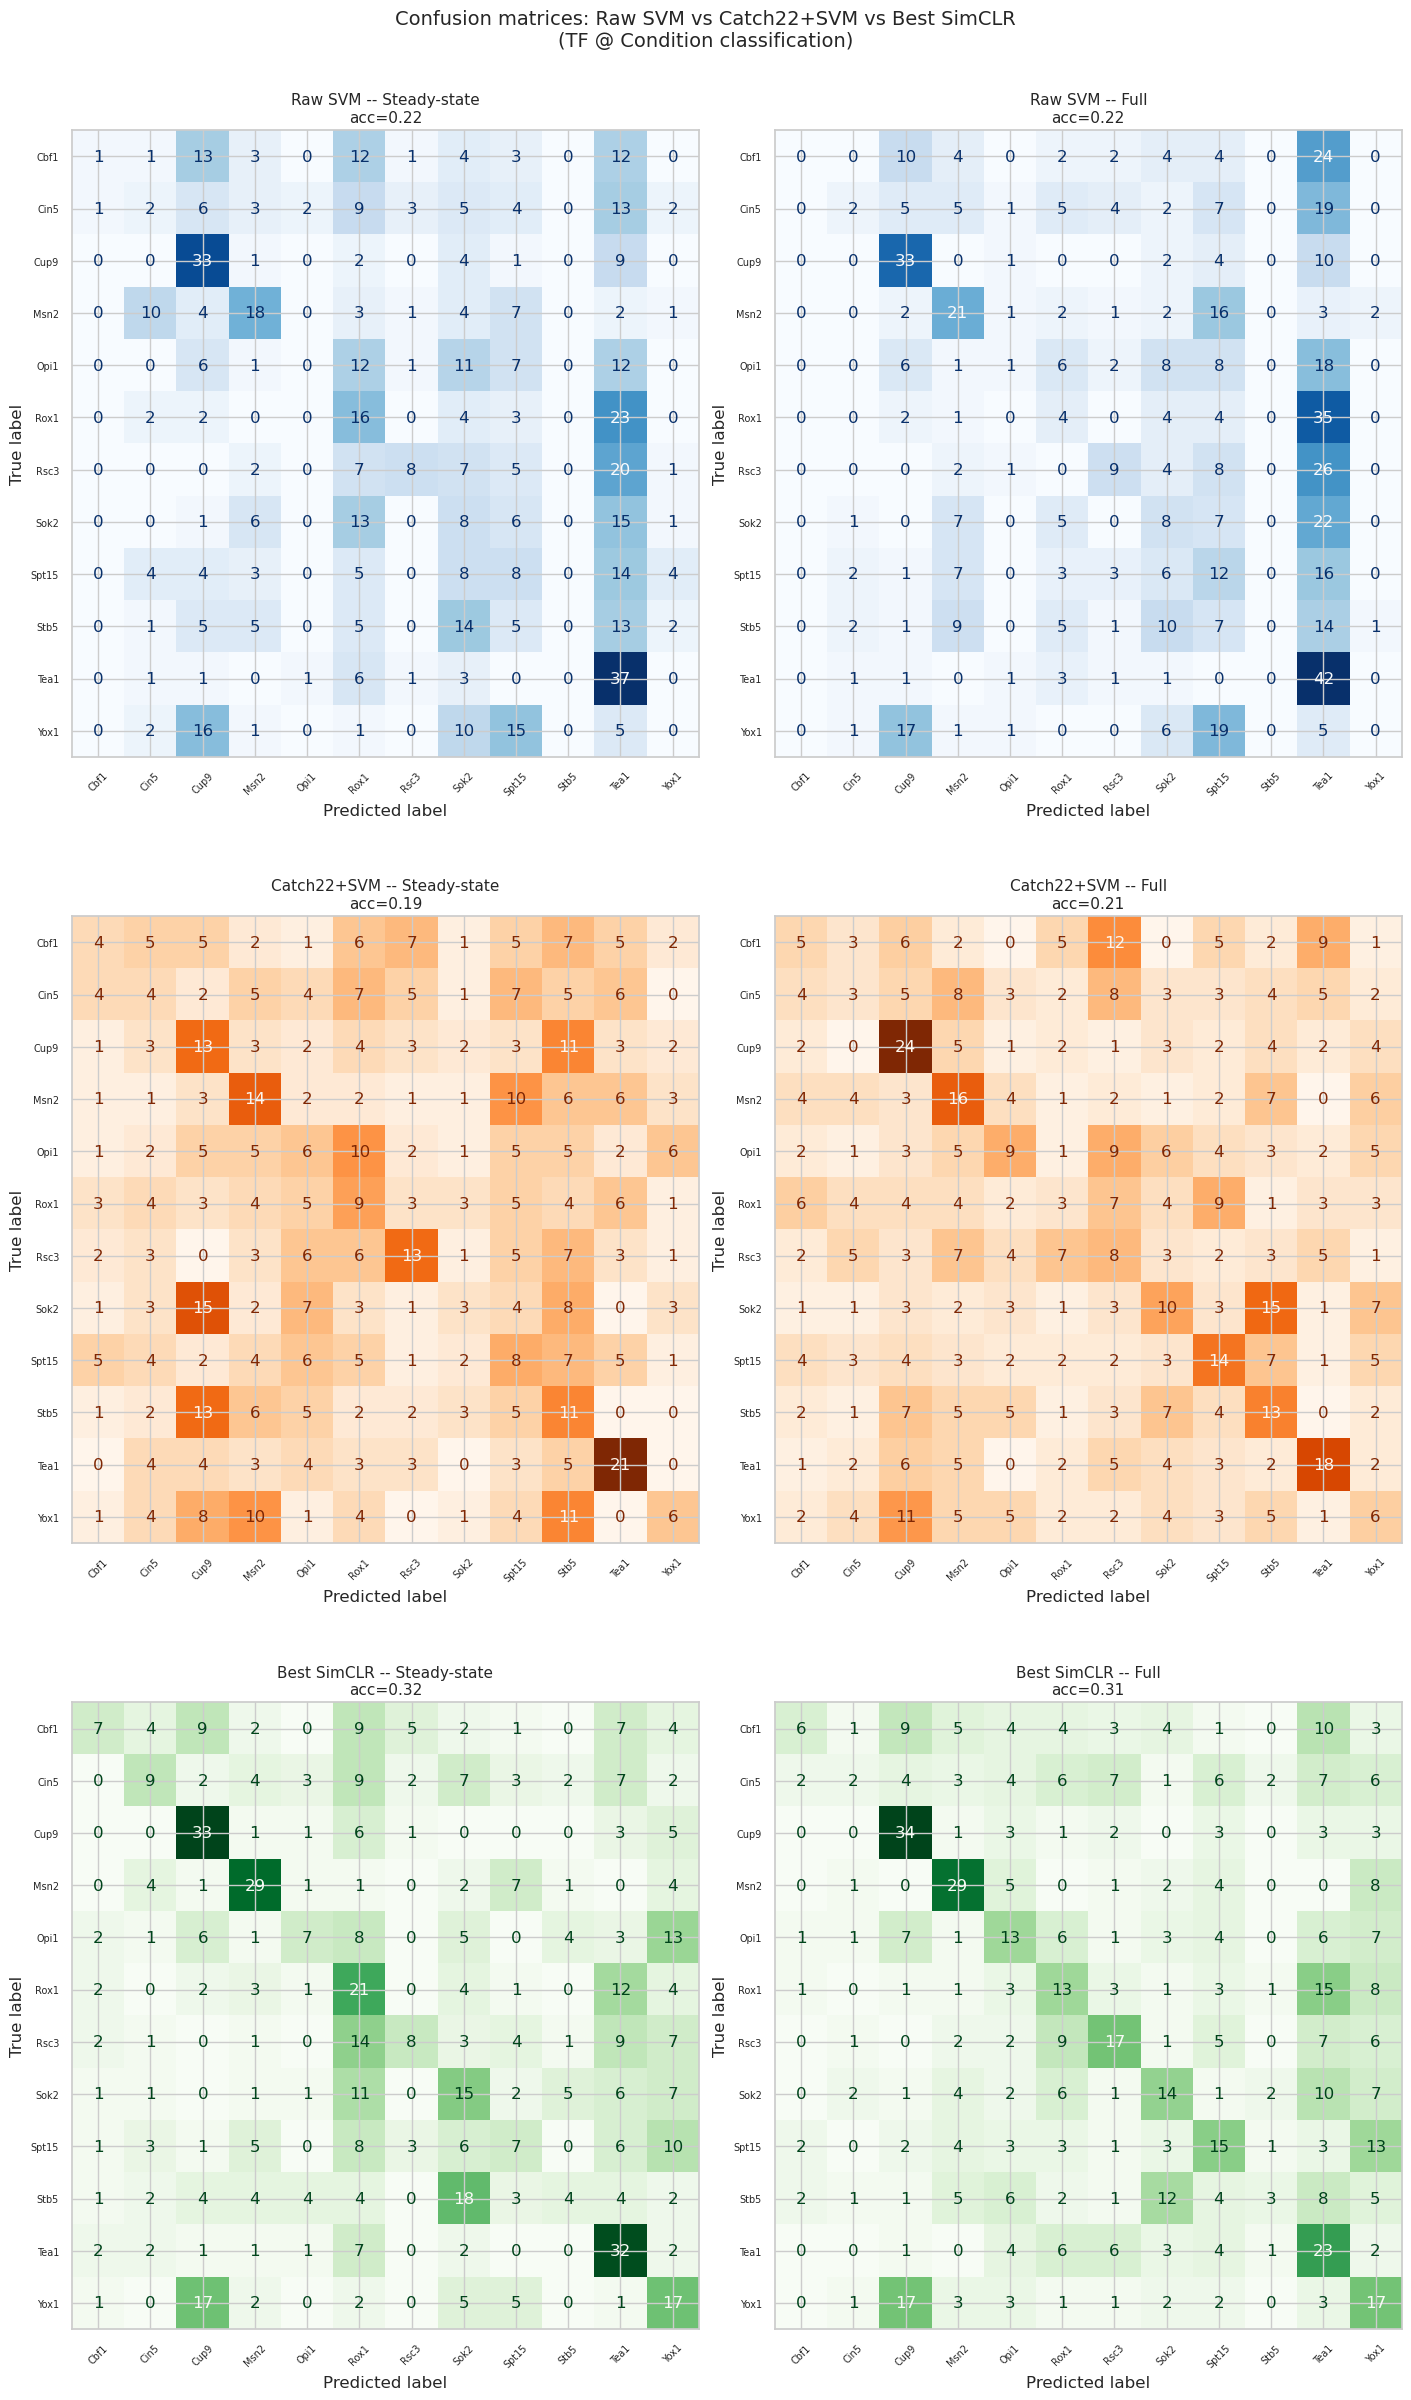

In [11]:
# ── SimCLR bar charts with Raw SVM & Catch22 as reference lines ─────────────
ss_simclr_valid   = ss_simclr_df[ss_simclr_df["status"] == "ok"]
full_simclr_valid = full_simclr_df[full_simclr_df["status"] == "ok"]


def plot_simclr_bar(valid, d, dataset_tag, svm_acc, c22_acc, fig_path):
    'All-checkpoint bar chart with baselines drawn as reference lines.'
    n_cls  = len(d["class_names"])
    chance = 1.0 / n_cls
    bar_colors = [EXP_COLOR_MAP.get(exp, (0.5,) * 3) for exp in valid["experiment"]]
    fig, ax = plt.subplots(figsize=(max(14, len(valid) * 0.55), 5), constrained_layout=True)
    bars = ax.bar(range(len(valid)), valid["accuracy"],
                  color=bar_colors, alpha=0.85, edgecolor="black")
    ax.axhline(svm_acc, color="grey",  linestyle="--", lw=1.5,
               label=f"Raw SVM ({svm_acc:.2f})")
    ax.axhline(c22_acc, color="black", linestyle=":",  lw=1.5,
               label=f"Catch22+SVM ({c22_acc:.2f})")
    ax.axhline(chance,  color="red",   linestyle="-",  lw=1.0, alpha=0.5,
               label=f"Chance ({chance:.2f})")
    ax.set_xticks(range(len(valid)))
    ax.set_xticklabels(valid["label"], rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Test accuracy")
    ax.set_title(f"SimCLR+SVM -- {dataset_tag} ({n_cls} classes, T={d['min_T']} tp)")
    ax.grid(axis="y", alpha=0.3)
    for bar, acc in zip(bars, valid["accuracy"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{acc:.2f}", ha="center", va="bottom", fontsize=7)
    palette = sns.color_palette("colorblind")
    legend_handles = [
        Patch(color=EXP_COLOR_MAP.get(_d, palette[7]), label=_d.replace("EXP-26-", ""))
        for _d in CKPT_DIRS
    ] + [
        plt.Line2D([0], [0], color="grey",  ls="--", label=f"Raw SVM ({svm_acc:.2f})"),
        plt.Line2D([0], [0], color="black", ls=":",  label=f"Catch22+SVM ({c22_acc:.2f})"),
        plt.Line2D([0], [0], color="red",   ls="-",  alpha=0.5, label=f"Chance ({chance:.2f})"),
    ]
    ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")
    plt.show()


plot_simclr_bar(ss_simclr_valid,   ss,   "Steady-state",
                ss_svm_acc,   ss_c22_acc,
                IY031_DIR / "IY031_NEW_tf_condition_ss_simclr_results.png")
plot_simclr_bar(full_simclr_valid, full, "Full",
                full_svm_acc, full_c22_acc,
                IY031_DIR / "IY031_NEW_tf_condition_full_simclr_results.png")


# ── Summary: Raw SVM vs Catch22+SVM vs best SimCLR ──────────────────────────
ss_best   = ss_simclr_valid.iloc[0]
full_best = full_simclr_valid.iloc[0]
ss_chance   = 1.0 / len(ss["class_names"])
full_chance = 1.0 / len(full["class_names"])

palette = sns.color_palette("colorblind")
methods = ["Raw SVM", "Catch22+SVM", f"Best SimCLR\n({ss_best['label']})"]
x       = np.arange(2)
width   = 0.22

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
for i, (ss_val, full_val) in enumerate(zip(
    [ss_svm_acc,   ss_c22_acc,   ss_best["accuracy"]],
    [full_svm_acc, full_c22_acc, full_best["accuracy"]],
)):
    bars = ax.bar(x + (i - 1) * width, [ss_val, full_val], width=width * 0.9,
                  label=methods[i], color=palette[i], alpha=0.85, edgecolor="black")
    for bar, v in zip(bars, [ss_val, full_val]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=9)

ax.plot(x[0] + np.array([-0.42, 0.42]), [ss_chance,   ss_chance],   "r-", lw=1.5, alpha=0.6, label="Chance")
ax.plot(x[1] + np.array([-0.42, 0.42]), [full_chance, full_chance], "r-", lw=1.5, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels([f"Steady-state\n({len(ss['class_names'])} classes)",
                    f"Full traces\n({len(full['class_names'])} classes)"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test accuracy")
ax.set_title("Raw SVM vs Catch22+SVM vs Best SimCLR\n(TF @ Condition classification)", fontsize=14)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
ax.grid(axis="y", alpha=0.3)
fig.savefig(IY031_DIR / "IY031_NEW_tf_condition_summary_comparison.png", dpi=150, bbox_inches="tight")
print(f"Saved: IY031_NEW_tf_condition_summary_comparison.png")
plt.show()

print(f"\nBest SimCLR -- SS:   {ss_best['label']}  acc={ss_best['accuracy']:.4f}")
print(f"Best SimCLR -- Full: {full_best['label']}  acc={full_best['accuracy']:.4f}")


# ── Confusion matrices: 3 methods x 2 datasets ──────────────────────────────
n_cls_max = max(len(ss["class_names"]), len(full["class_names"]))
cm_h      = max(5, n_cls_max * 0.5 + 2)

fig, axes = plt.subplots(3, 2, figsize=(7 * 2, cm_h * 3), constrained_layout=True)
cm_entries = [
    (axes[0, 0], ss,   "Raw SVM",       ss_svm_pred,                              "Steady-state"),
    (axes[0, 1], full, "Raw SVM",       full_svm_pred,                            "Full"),
    (axes[1, 0], ss,   "Catch22+SVM",   ss_c22_pred,                              "Steady-state"),
    (axes[1, 1], full, "Catch22+SVM",   full_c22_pred,                            "Full"),
    (axes[2, 0], ss,   "Best SimCLR",   ss_simclr_preds[ss_best["checkpoint"]],   "Steady-state"),
    (axes[2, 1], full, "Best SimCLR",   full_simclr_preds[full_best["checkpoint"]], "Full"),
]
cm_palette = {"Raw SVM": "Blues", "Catch22+SVM": "Oranges", "Best SimCLR": "Greens"}
for ax, d, method, y_pred, dataset_tag in cm_entries:
    acc = accuracy_score(d["y_test"], y_pred)
    ConfusionMatrixDisplay.from_predictions(
        d["y_test"], y_pred,
        display_labels=d["class_names"],
        ax=ax, colorbar=False, cmap=cm_palette[method], xticks_rotation=45,
    )
    ax.set_title(f"{method} -- {dataset_tag}\nacc={acc:.2f}", fontsize=11)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Confusion matrices: Raw SVM vs Catch22+SVM vs Best SimCLR\n"
             "(TF @ Condition classification)", fontsize=14)
fig.savefig(IY031_DIR / "IY031_NEW_tf_condition_confusion_matrices.png", dpi=150, bbox_inches="tight")
print(f"Saved: IY031_NEW_tf_condition_confusion_matrices.png")
plt.show()
